In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_csv("diamonds.csv")
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  int64  
 2   color    53940 non-null  int64  
 3   clarity  53940 non-null  int64  
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   x        53940 non-null  float64
 7   y        53940 non-null  float64
 8   z        53940 non-null  float64
 9   price    53940 non-null  int64  
dtypes: float64(6), int64(4)
memory usage: 4.1 MB


In [ ]:
# from sklearn.preprocessing import OneHotEncoder

# oneHotEncoder_column = ["cut" , "color" , "clarity"]

# oh = OneHotEncoder(sparse_output=False)

# new_df = oh.fit_transform(df[oneHotEncoder_column])
# new_df = pd.DataFrame(new_df , columns = oh.get_feature_names_out(oneHotEncoder_column))
# df = pd.concat([df , new_df] , axis = 1)
# df.drop(oneHotEncoder_column , axis = 1 , inplace = True)


In [54]:
from sklearn.preprocessing import LabelEncoder

labeled_columns = ["cut" , "color" , "clarity"]

for col in labeled_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


In [56]:
x = df.drop(["price"] , axis=1)
y = df["price"]

In [57]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x = scaler.fit_transform(x)

In [58]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x , y , random_state=42 , test_size=0.3)

In [59]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators = 1500,
    learning_rate = 0.05,
    max_depth = 7,
)

model.fit(x_train , y_train)

,"base_score base_score: typing.Optional[float]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[str], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. See:py:class:`DMatrix` for details.,None


In [70]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators = 1500,
    max_depth = 5,
    random_state=42
)

model.fit(x_train , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [71]:
y_pred = model.predict(x_test)

In [61]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

mae = mean_absolute_error(y_test , y_pred)
mse = mean_squared_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)

print("mae" , mae)
print("mse" , mse)
print("r2" , r2)

mae 266.65435791015625
mse 294198.4375
r2 0.9811362624168396


In [72]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

mae = mean_absolute_error(y_test , y_pred)
mse = mean_squared_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)

print("mae" , mae)
print("mse" , mse)
print("r2" , r2)

mae 556.0309370146077
mse 981132.2704556084
r2 0.9370906273629129



========== Predictions ==========
       Actual     Predicted        Error  Absolute_Error  Error_Percent
1388      559    532.804810    26.195190       26.195190       4.686081
50052    2201   2358.507324  -157.507324      157.507324       7.156171
41645    1238   1201.620605    36.379395       36.379395       2.938562
42377    1304   1330.127563   -26.127563       26.127563       2.003648
17244    6901   9336.292969 -2435.292969     2435.292969      35.288987
1608     3011   3874.733643  -863.733643      863.733643      28.685940
46398    1765   1768.846436    -3.846436        3.846436       0.217928
45493    1679   1825.739624  -146.739624      146.739624       8.739704
49385    2102   2090.210205    11.789795       11.789795       0.560885
10460    4789   5686.493652  -897.493652      897.493652      18.740732
34243     855    832.568726    22.431274       22.431274       2.623541
24772   13134  13779.951172  -645.951172      645.951172       4.918160
42987    1367   1407.877441  

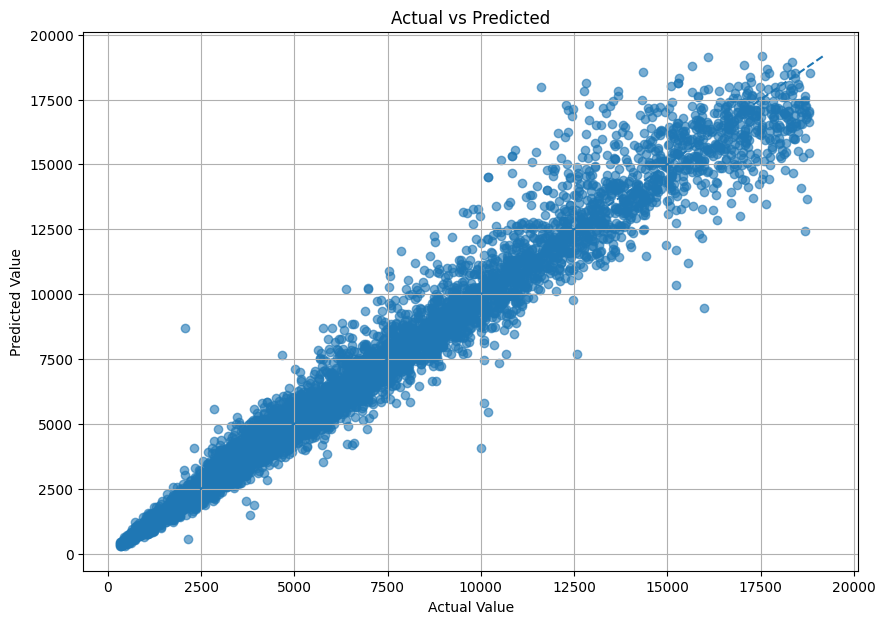

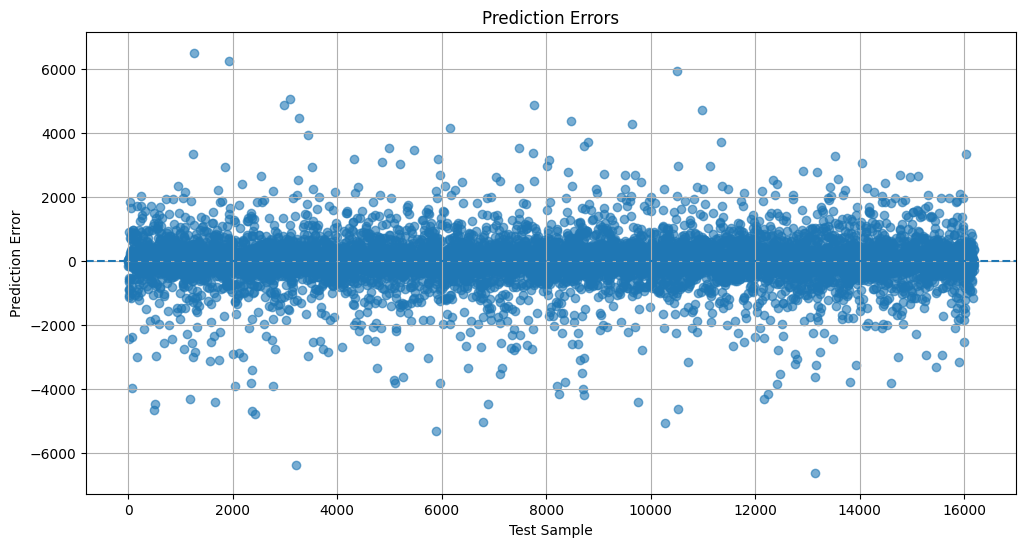

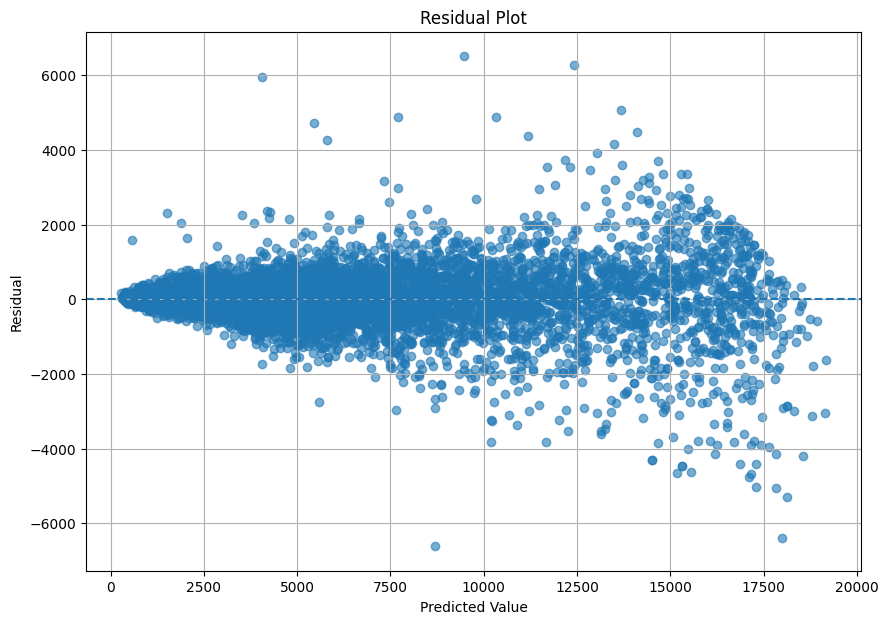

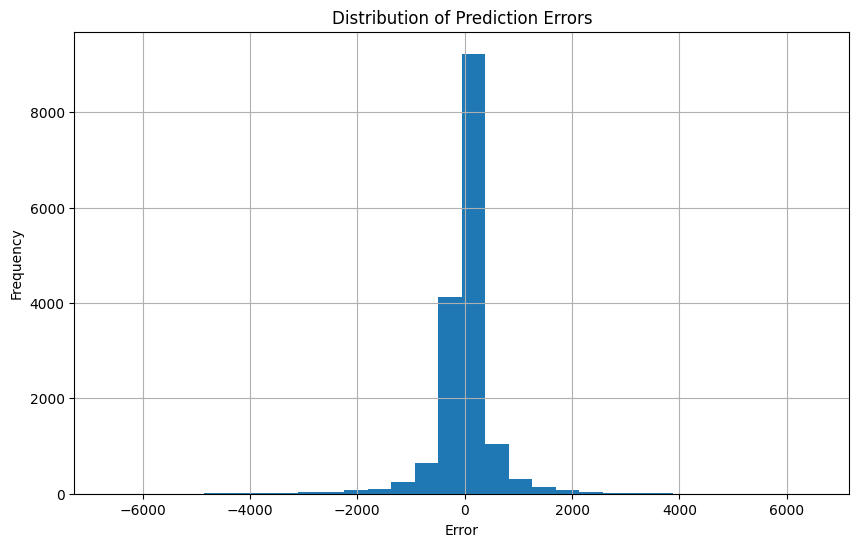


========== Worst Predictions ==========
       Actual     Predicted        Error  Absolute_Error  Error_Percent
49189    2075   8689.496094 -6614.496094     6614.496094     318.770896
26444   15984   9472.226562  6511.773438     6511.773438      40.739323
23587   11602  17990.541016 -6388.541016     6388.541016      55.064136
27673   18691  12426.601562  6264.398438     6264.398438      33.515587
21935   10011   4065.323486  5945.676514     5945.676514      59.391435
24539   12829  18136.113281 -5307.113281     5307.113281      41.368098
27726   18745  13666.578125  5078.421875     5078.421875      27.092141
24492   12766  17822.519531 -5056.519531     5056.519531      39.609271
24115   12271  17301.005859 -5030.005859     5030.005859      40.991002
25999   15223  10332.886719  4890.113281     4890.113281      32.123190
24328   12587   7697.460449  4889.539551     4889.539551      38.845949
24165   12341  17109.054688 -4768.054688     4768.054688      38.635886
22142   10181   5444.77

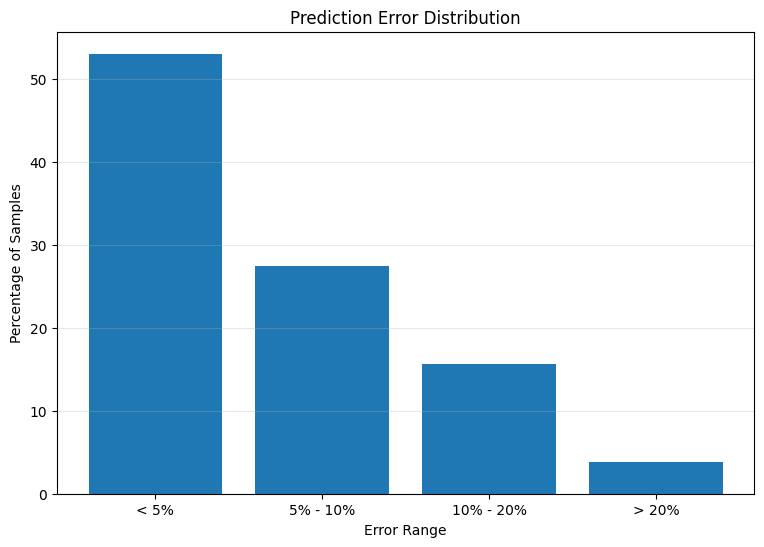

In [66]:
errors = y_test - y_pred

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Error": errors,
    "Absolute_Error": np.abs(errors)
})


# درصد خطا
results["Error_Percent"] = (
    np.abs(
        (results["Actual"] - results["Predicted"])
        / results["Actual"]
    ) * 100
)


print("\n========== Predictions ==========")

print(results.head(20))


# ==========================================
# 4. نمودار Actual vs Predicted
# ==========================================

plt.figure(figsize=(10, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# خط ایده‌آل
min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()


# ==========================================
# 5. نمودار خطاها
# ==========================================

plt.figure(figsize=(12, 6))

plt.scatter(
    range(len(errors)),
    errors,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Test Sample")
plt.ylabel("Prediction Error")

plt.title("Prediction Errors")

plt.grid(True)

plt.show()


# ==========================================
# 6. Residual Plot
# ==========================================

plt.figure(figsize=(10, 7))

plt.scatter(
    y_pred,
    errors,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Value")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()


# ==========================================
# 7. توزیع خطاها
# ==========================================

plt.figure(figsize=(10, 6))

plt.hist(
    errors,
    bins=30
)

plt.xlabel("Error")
plt.ylabel("Frequency")

plt.title("Distribution of Prediction Errors")

plt.grid(True)

plt.show()


# ==========================================
# 8. نمایش بدترین پیش‌بینی‌ها
# ==========================================

worst_predictions = results.sort_values(
    by="Absolute_Error",
    ascending=False
)

print("\n========== Worst Predictions ==========")

print(
    worst_predictions.head(20)
)


# ==========================================
# 9. درصد نمونه‌ها بر اساس میزان خطا
# ==========================================

less_5 = (results["Error_Percent"] < 5).mean() * 100

between_5_10 = (
    (
        (results["Error_Percent"] >= 5) &
        (results["Error_Percent"] < 10)
    ).mean() * 100
)

between_10_20 = (
    (
        (results["Error_Percent"] >= 10) &
        (results["Error_Percent"] < 20)
    ).mean() * 100
)

more_20 = (
    (results["Error_Percent"] >= 20).mean() * 100
)


print("\n========== Error Percentage ==========")

print(f"Error < 5%    : {less_5:.2f}%")
print(f"5% - 10%      : {between_5_10:.2f}%")
print(f"10% - 20%     : {between_10_20:.2f}%")
print(f"Error > 20%   : {more_20:.2f}%")


# ==========================================
# 10. نمودار درصد خطا
# ==========================================

categories = [
    "< 5%",
    "5% - 10%",
    "10% - 20%",
    "> 20%"
]

values = [
    less_5,
    between_5_10,
    between_10_20,
    more_20
]

plt.figure(figsize=(9, 6))

plt.bar(
    categories,
    values
)

plt.xlabel("Error Range")
plt.ylabel("Percentage of Samples")

plt.title("Prediction Error Distribution")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()